# ResNet-18 Unfreeze + Penalty Regularization

## Motivation
The unfrozen ResNet baseline showed heavy overfitting â€” train F2 reached ~0.97 while val F2 plateaued ~0.74. This notebook adds explicit L1/L2 weight penalty terms directly to the loss to constrain weight magnitudes and reduce overfitting.

## Why explicit penalty vs `weight_decay` in Adam?
Adam's `weight_decay` parameter is **not** equivalent to L2 penalty. Adam scales updates by per-parameter gradient magnitude, so `weight_decay` acts more like a scaled shrinkage rather than a true L2 penalty. Adding the penalty directly to the loss gives the correct, unscaled regularization effect.

## Lambda Sweep
| Run | l1_lambda | l2_lambda | Purpose |
|-----|-----------|-----------|--------|
| 0   | 0         | 0         | Baseline (no penalty) |
| 1   | 0         | 1e-4      | Mild L2 |
| 2   | 0         | 1e-3      | Moderate L2 |
| 3   | 0         | 1e-2      | Strong L2 |
| 4   | 1e-4      | 0         | Mild L1 |

In [1]:
import sys
import os
from pathlib import Path

# Find project root regardless of CWD (works in VS Code, Jupyter Lab, etc.)
ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import fbeta_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

from src.data.dataloader import get_dataloaders
from src.models.resnet import get_resnet
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.data.transform import get_augmented_train_transforms

os.chdir(ROOT)
print(Path.cwd())

c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning


In [ ]:
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.mps.manual_seed(seed)

set_seed(42)

In [ ]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

CUDA available: True
MPS available: False
Using device: cuda


In [ ]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv='data_new/splits/train.csv',
    val_csv='data_new/splits/val.csv',
    test_csv='data_new/splits/test.csv',
    image_dir='data_new/images/train',
    test_image_dir='data_new/images/test',
    batch_size=32,
    image_size=224,
    num_workers=0,
)

train_df = pd.read_csv('data_new/splits/train.csv')

num_melanoma = (train_df['label'] == 1).sum()   # melanoma in CSV (label=1)
num_nevus = (train_df['label'] == 0).sum()      # nevus in CSV (label=0)

pos_weight = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)

print('Positive weight:', pos_weight)

Positive weight: tensor([6.0244], device='cuda:0')


## Lambda Sweep

In [5]:
all_results = {}

## Baseline without penalty, L1 = 0, L2 = 0

In [ ]:
# --- Baseline (no penalty) ---
num_epochs = 20
run_label = 'Baseline'
l1_lambda = 0.0
l2_lambda = 0.0

print(f'=== Run: {run_label} (l1={l1_lambda}, l2={l2_lambda}) ===')
set_seed(42)

model = get_resnet(num_classes=1, freeze_backbone=False).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

history = {'train_loss': [], 'val_loss': [], 'train_f2': [], 'val_f2': []}
best_val_f2 = 0.0
best_state = None

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device, l1_lambda=l1_lambda, l2_lambda=l2_lambda)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['train_f2'].append(train_metrics['f2'])
    history['val_f2'].append(val_metrics['f2'])

    print(f"  Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_metrics['loss']:.4f}, F2: {train_metrics['f2']:.4f} | Val Loss: {val_metrics['loss']:.4f}, F2: {val_metrics['f2']:.4f}")

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f'    -> New best val F2: {best_val_f2:.4f}')

all_results[run_label] = {'history': history, 'best_val_f2': best_val_f2, 'best_state': best_state}
print(f'Best val F2 for {run_label}: {best_val_f2:.4f}')

In [16]:
# --- L2=1e-3 ---
num_epochs = 30
run_label = 'L2=1e-4'
l1_lambda = 0.0
l2_lambda = 1e-3

print(f'=== Run: {run_label} (l1={l1_lambda}, l2={l2_lambda}) ===')
set_seed(42)

model = get_resnet(num_classes=1, freeze_backbone=False).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

history = {'train_loss': [], 'val_loss': [], 'train_f2': [], 'val_f2': []}
best_val_f2 = 0.0
best_state = None

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device, l1_lambda=l1_lambda, l2_lambda=l2_lambda)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['train_f2'].append(train_metrics['f2'])
    history['val_f2'].append(val_metrics['f2'])

    print(f"  Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_metrics['loss']:.4f}, F2: {train_metrics['f2']:.4f} | Val Loss: {val_metrics['loss']:.4f}, F2: {val_metrics['f2']:.4f}")

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f'    -> New best val F2: {best_val_f2:.4f}')

all_results[run_label] = {'history': history, 'best_val_f2': best_val_f2, 'best_state': best_state}
print(f'Best val F2 for {run_label}: {best_val_f2:.4f}')

=== Run: L2=1e-4 (l1=0.0, l2=0.001) ===


  Epoch [1/30] | Train Loss: 0.7358, F2: 0.6640 | Val Loss: 0.6592, F2: 0.6698
    -> New best val F2: 0.6698


  Epoch [2/30] | Train Loss: 0.6443, F2: 0.6957 | Val Loss: 0.8529, F2: 0.6327


  Epoch [3/30] | Train Loss: 0.6299, F2: 0.7102 | Val Loss: 0.6984, F2: 0.6937
    -> New best val F2: 0.6937


  Epoch [4/30] | Train Loss: 0.6020, F2: 0.7157 | Val Loss: 0.6398, F2: 0.6923


...

  Epoch [26/30] | Train Loss: 0.3952, F2: 0.8227 | Val Loss: 0.6904, F2: 0.7294
    -> New best val F2: 0.7294


  Epoch [27/30] | Train Loss: 0.3855, F2: 0.8259 | Val Loss: 0.8151, F2: 0.7274


  Epoch [28/30] | Train Loss: 0.3662, F2: 0.8442 | Val Loss: 0.6845, F2: 0.7223


  Epoch [29/30] | Train Loss: 0.3840, F2: 0.8307 | Val Loss: 0.6801, F2: 0.7310
    -> New best val F2: 0.7310


  Epoch [30/30] | Train Loss: 0.3422, F2: 0.8500 | Val Loss: 0.7147, F2: 0.7371
    -> New best val F2: 0.7371
Best val F2 for L2=1e-4: 0.7371


In [8]:
# --- L1=1e-3 + ReduceLROnPlateau ---
num_epochs = 30
run_label = 'L1=1e-3+LR'
l1_lambda = 1e-3
l2_lambda = 0.0

print(f'=== Run: {run_label} (l1={l1_lambda}, l2={l2_lambda}) ===')
set_seed(42)

model = get_resnet(num_classes=1, freeze_backbone=False).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=4, factor=0.5, verbose=False)

history = {'train_loss': [], 'val_loss': [], 'train_f2': [], 'val_f2': []}
best_val_f2 = 0.0
best_state = None

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device, l1_lambda=l1_lambda, l2_lambda=l2_lambda)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['train_f2'].append(train_metrics['f2'])
    history['val_f2'].append(val_metrics['f2'])

    scheduler.step(val_metrics['f2'])
    current_lr = optimizer.param_groups[0]['lr']

    print(f"  Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_metrics['loss']:.4f}, F2: {train_metrics['f2']:.4f} | Val Loss: {val_metrics['loss']:.4f}, F2: {val_metrics['f2']:.4f} | LR: {current_lr:.2e}")

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f'    -> New best val F2: {best_val_f2:.4f}')

all_results[run_label] = {'history': history, 'best_val_f2': best_val_f2, 'best_state': best_state}
print(f'Best val F2 for {run_label}: {best_val_f2:.4f}')

c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning\dl_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


=== Run: L1=1e-3+LR (l1=0.001, l2=0.0) ===


  Epoch [1/30] | Train Loss: 0.7246, F2: 0.6754 | Val Loss: 0.6834, F2: 0.6735 | LR: 1.00e-04
    -> New best val F2: 0.6735


  Epoch [2/30] | Train Loss: 0.6663, F2: 0.6947 | Val Loss: 0.7667, F2: 0.6690 | LR: 1.00e-04


  Epoch [3/30] | Train Loss: 0.6790, F2: 0.6996 | Val Loss: 0.6647, F2: 0.7049 | LR: 1.00e-04
    -> New best val F2: 0.7049


...

  Epoch [26/30] | Train Loss: 0.5361, F2: 0.7516 | Val Loss: 0.6349, F2: 0.7101 | LR: 1.25e-05


  Epoch [27/30] | Train Loss: 0.5461, F2: 0.7356 | Val Loss: 0.6484, F2: 0.7081 | LR: 1.25e-05


  Epoch [28/30] | Train Loss: 0.5377, F2: 0.7447 | Val Loss: 0.6466, F2: 0.6953 | LR: 1.25e-05


  Epoch [29/30] | Train Loss: 0.5363, F2: 0.7443 | Val Loss: 0.6439, F2: 0.7064 | LR: 6.25e-06


  Epoch [30/30] | Train Loss: 0.5130, F2: 0.7633 | Val Loss: 0.6360, F2: 0.6842 | LR: 6.25e-06
Best val F2 for L1=1e-3+LR: 0.7244


In [ ]:
# --- L1=1e-3 + L2=1e-3 + ReduceLROnPlateau ---
num_epochs = 30
run_label = 'L1=1e-3+LR'
l1_lambda = 1e-3
l2_lambda = 1e-3

print(f'=== Run: {run_label} (l1={l1_lambda}, l2={l2_lambda}) ===')
set_seed(42)

model = get_resnet(num_classes=1, freeze_backbone=False).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=4, factor=0.5, verbose=False)

history = {'train_loss': [], 'val_loss': [], 'train_f2': [], 'val_f2': []}
best_val_f2 = 0.0
best_state = None

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device, l1_lambda=l1_lambda, l2_lambda=l2_lambda)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['train_f2'].append(train_metrics['f2'])
    history['val_f2'].append(val_metrics['f2'])

    scheduler.step(val_metrics['f2'])
    current_lr = optimizer.param_groups[0]['lr']

    print(f"  Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_metrics['loss']:.4f}, F2: {train_metrics['f2']:.4f} | Val Loss: {val_metrics['loss']:.4f}, F2: {val_metrics['f2']:.4f} | LR: {current_lr:.2e}")

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f'    -> New best val F2: {best_val_f2:.4f}')

all_results[run_label] = {'history': history, 'best_val_f2': best_val_f2, 'best_state': best_state}
print(f'Best val F2 for {run_label}: {best_val_f2:.4f}')

## Compare Overfitting: Train vs Val F2 Gap

In [17]:
print(f"{'Run':<12} | {'Best Val F2':>11} | {'Final Train F2':>14} | {'Final Val F2':>12} | {'Gap (T-V)':>9}")
print('-' * 70)
for run_label, result in all_results.items():
    h = result['history']
    final_train_f2 = h['train_f2'][-1]
    final_val_f2 = h['val_f2'][-1]
    gap = final_train_f2 - final_val_f2
    print(f"{run_label:<12} | {result['best_val_f2']:>11.4f} | {final_train_f2:>14.4f} | {final_val_f2:>12.4f} | {gap:>9.4f}")

Run          | Best Val F2 | Final Train F2 | Final Val F2 | Gap (T-V)
----------------------------------------------------------------------
L2=1e-4      |      0.7371 |         0.8500 |       0.7371 |    0.1129
L1=1e-3+LR   |      0.7244 |         0.7633 |       0.6842 |    0.0792


## Compare Overfitting: Train vs Val Loss Gap

In [18]:
print(f"{'Run':<12} | {'Final Train Loss':>15} | {'Final Val Loss':>14} | {'Loss Gap (V-T)':>14}")
print('-' * 62)
for run_label, result in all_results.items():
    h = result['history']
    final_train_loss = h['train_loss'][-1]
    final_val_loss = h['val_loss'][-1]
    gap = final_val_loss - final_train_loss
    print(f"{run_label:<12} | {final_train_loss:>15.4f} | {final_val_loss:>14.4f} | {gap:>14.4f}")

Run          | Final Train Loss | Final Val Loss | Loss Gap (V-T)
--------------------------------------------------------------
L2=1e-4      |          0.3422 |         0.7147 |         0.3725
L1=1e-3+LR   |          0.5130 |         0.6360 |         0.1231


## Test Set Comparison: All Runs

In [19]:
from sklearn.metrics import recall_score, precision_score

print(f"{'Run':<12} | {'Test Loss':>9} | {'Test Recall':>11} | {'Test Prec':>10} | {'Test F2':>9}")
print('-' * 62)

for run_label, result in all_results.items():
    eval_model = get_resnet(num_classes=1, freeze_backbone=False).to(device)
    eval_model.load_state_dict({k: v.to(device) for k, v in result['best_state'].items()})
    eval_model.eval()

    criterion_eval = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    running_loss = 0.0
    total_samples = 0
    all_labels_test = []
    all_probs_test = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels_dev = labels.float().unsqueeze(1).to(device)
            outputs = eval_model(images)
            loss = criterion_eval(outputs, labels_dev)
            running_loss += loss.item() * images.size(0)
            total_samples += images.size(0)
            probs = torch.sigmoid(outputs).squeeze(1)
            all_probs_test.extend(probs.cpu().numpy())
            all_labels_test.extend(labels.numpy())

    test_loss = running_loss / total_samples

    val_probs_run, val_labels_run = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            outputs = eval_model(images.to(device))
            probs = torch.sigmoid(outputs).squeeze(1)
            val_probs_run.extend(probs.cpu().numpy())
            val_labels_run.extend(labels.numpy())

    thresholds = np.arange(0.01, 0.9, 0.01)
    f2_scores = [fbeta_score(val_labels_run, (np.array(val_probs_run) >= t).astype(int), beta=2, pos_label=1, zero_division=0) for t in thresholds]
    best_threshold = thresholds[np.argmax(f2_scores)]

    preds = (np.array(all_probs_test) >= best_threshold).astype(int)
    test_f2 = fbeta_score(all_labels_test, preds, beta=2, pos_label=1, zero_division=0)
    test_recall = recall_score(all_labels_test, preds, pos_label=1, zero_division=0)
    test_precision = precision_score(all_labels_test, preds, pos_label=1, zero_division=0)

    print(f"{run_label:<12} | {test_loss:>9.4f} | {test_recall:>11.4f} | {test_precision:>10.4f} | {test_f2:>9.4f}")

## Training Curves

#### Plot Train vs Val Loss

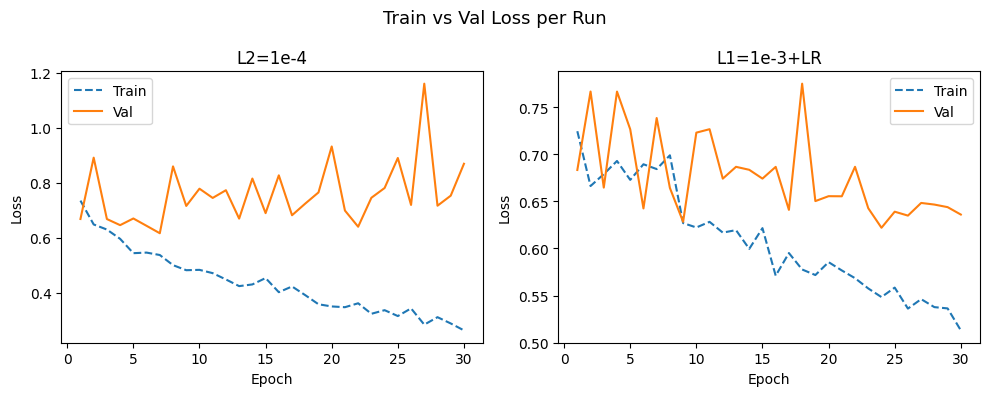

In [10]:
n_runs = len(all_results)
n_cols = 2
n_rows = (n_runs + 1) // 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows), sharey=False)
axes = axes.flatten()

for ax, (run_label, result) in zip(axes, all_results.items()):
    h = result['history']
    epochs = range(1, len(h['train_loss']) + 1)
    ax.plot(epochs, h['train_loss'], label='Train', linestyle='--')
    ax.plot(epochs, h['val_loss'], label='Val')
    ax.set_title(run_label)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()

for ax in axes[n_runs:]:
    ax.set_visible(False)

fig.suptitle('Train vs Val Loss per Run', fontsize=13)
plt.tight_layout()
plt.show()

#### Plot Train vs Val F2

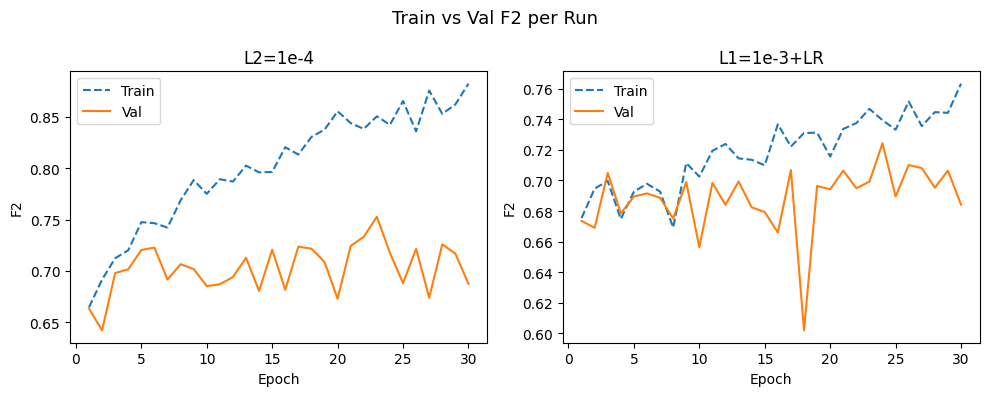

In [11]:
n_runs = len(all_results)
n_cols = 2
n_rows = (n_runs + 1) // 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows), sharey=False)
axes = axes.flatten()

for ax, (run_label, result) in zip(axes, all_results.items()):
    h = result['history']
    epochs = range(1, len(h['train_f2']) + 1)
    ax.plot(epochs, h['train_f2'], label='Train', linestyle='--')
    ax.plot(epochs, h['val_f2'], label='Val')
    ax.set_title(run_label)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('F2')
    ax.legend()

for ax in axes[n_runs:]:
    ax.set_visible(False)

fig.suptitle('Train vs Val F2 per Run', fontsize=13)
plt.tight_layout()
plt.show()

## Save & Evaluate Best Run

In [ ]:
best_run_label = max(all_results, key=lambda k: all_results[k]['best_val_f2'])
print(f'Best run: {best_run_label} (val F2 = {all_results[best_run_label]["best_val_f2"]:.4f})')

best_model = get_resnet(num_classes=1, freeze_backbone=False).to(device)
best_model.load_state_dict({k: v.to(device) for k, v in all_results[best_run_label]['best_state'].items()})

torch.save(best_model.state_dict(), 'models/resnet_unfreeze_penalty_best.pth')
print('Saved to models/resnet_unfreeze_penalty_best.pth')

Best run: L2=1e-4 (val F2 = 0.7527)
Saved to models/resnet_unfreeze_penalty_best.pth


## Threshold Tuning

In [13]:
best_model.eval()

val_probs = []
val_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        outputs = best_model(images.to(device))
        probs = torch.sigmoid(outputs).squeeze(1)
        val_probs.extend(probs.cpu().numpy())
        val_labels.extend(labels.numpy())

thresholds = np.arange(0.01, 0.9, 0.01)
f2_scores = [
    fbeta_score(val_labels, (np.array(val_probs) >= t).astype(int), beta=2, pos_label=1, zero_division=0)
    for t in thresholds
]

best_threshold = thresholds[np.argmax(f2_scores)]
print(f'Best threshold: {best_threshold:.2f} | Val F2: {max(f2_scores):.4f}')

Best threshold: 0.49 | Val F2: 0.7558


## Test Set Evaluation

In [14]:
best_model.eval()

all_labels = []
all_probs = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = best_model(images)
        probs = torch.sigmoid(outputs).squeeze(1)
        preds = (probs >= best_threshold).long()

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
print('Confusion Matrix:')
print(cm)
print()
print(classification_report(all_labels, all_preds, digits=4))

Confusion Matrix:
[[916  90]
 [ 24 143]]

              precision    recall  f1-score   support

           0     0.9745    0.9105    0.9414      1006
           1     0.6137    0.8563    0.7150       167

    accuracy                         0.9028      1173
   macro avg     0.7941    0.8834    0.8282      1173
weighted avg     0.9231    0.9028    0.9092      1173



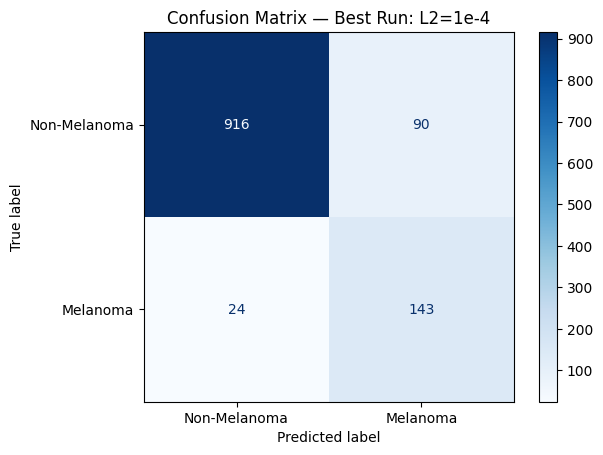

In [15]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Melanoma', 'Melanoma'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix â€” Best Run: {best_run_label}')
plt.show()